In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import math
import folium
from tqdm import tqdm
import rasterio
from rasterio.transform import rowcol
from rasterio.merge import merge
from rasterio.mask import mask
from pyproj import Transformer

import osmium

from sklearn.neighbors import BallTree
from tqdm import tqdm
import time

from matplotlib.lines import Line2D

from tqdm.auto import tqdm
from shapely.ops import unary_union

import osmnx as ox
import networkx as nx


from shapely.ops import nearest_points
from shapely.geometry import LineString, box

In [2]:
# DEFINICJE #

# MAPY #
france_regions_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/regions.geojson" 
france_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements-version-simplifiee.geojson" 

# TRZCIONKA NA WYKRESACH #
plt.rcParams.update({"axes.titlesize": 11.5, "axes.labelsize": 10, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5})

In [3]:
data3 = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_all2.txt', low_memory = False)

ids1 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_transaction_ids.txt", dtype=str)
ids2 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_one_outbuilding_transaction_ids.txt", dtype=str)
ids3 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_house_transaction_ids.txt", dtype=str)

features_ids = set(ids1) | set(ids2) | set(ids3) 

1. **gęstość zaludnienia**

In [4]:
tif_files = [
    "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R3_C19.tif",
    "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R4_C18.tif",
    "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R4_C19.tif",
    'GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R5_C19.tif',
    'GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R4_C20.tif'
]

tif_files = [f"D:\\nieruchomosci_ostateczne\\density\\{tif}" for tif in tif_files]
datasets = [rasterio.open(tif) for tif in tif_files]

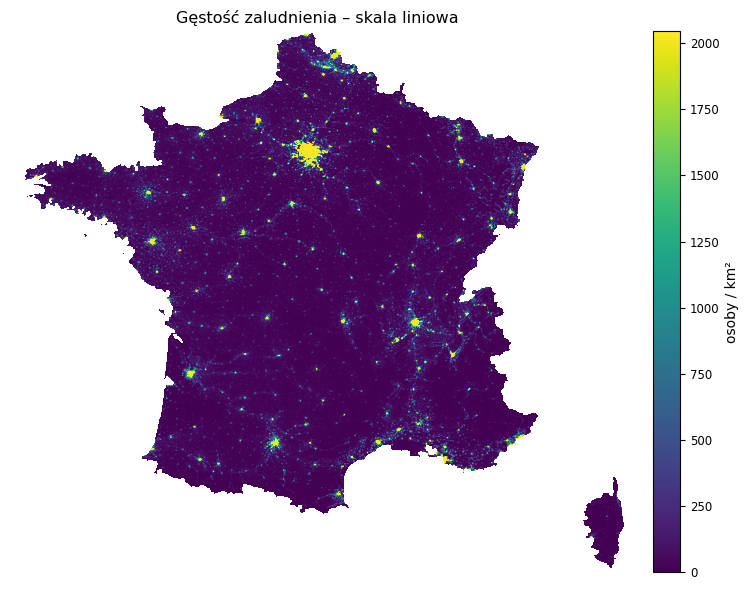

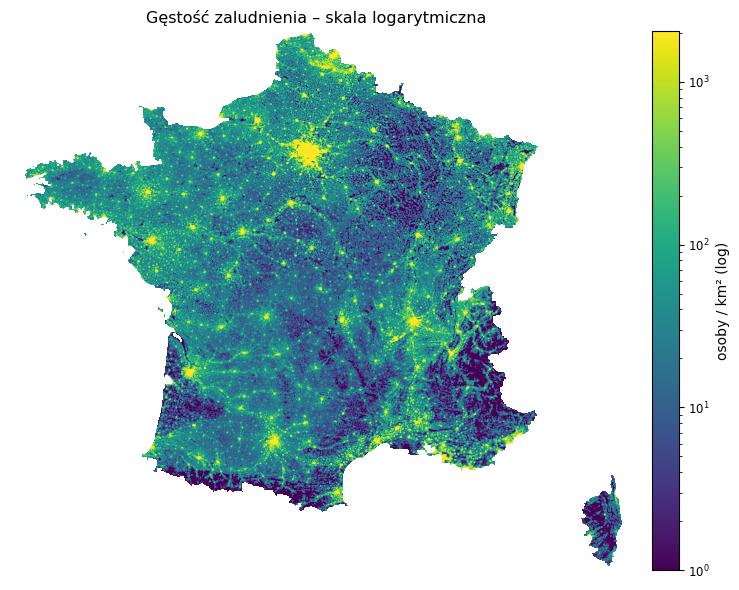

In [5]:
mosaic, mosaic_transform = merge(datasets)
mosaic_meta = datasets[0].meta.copy()
mosaic_meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2], "transform": mosaic_transform})

out_tif = r"D:\\nieruchomosci_ostateczne\\density\\ghs_pop_fr_mosaic.tif"

with rasterio.open(out_tif, "w", **mosaic_meta) as dst:
    dst.write(mosaic)

france = gpd.read_file(france_regions_map_url)
france_union = france.dissolve()   

with rasterio.open(out_tif) as src:
    france_union = france_union.to_crs(src.crs)
    out_image, out_transform = mask(src, france_union.geometry, crop=True)
    out_meta = src.meta.copy()
    out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})


data_fr = out_image[0].astype(float)
nodata = out_meta.get("nodata", None)

if nodata is not None:
    data_fr[data_fr == nodata] = np.nan

vmax_lin = np.nanpercentile(data_fr, 99)

# WYKRES: SKALA LINIOWA #
plt.figure(figsize=(8, 6))

im1 = plt.imshow(data_fr, origin="upper", cmap="viridis", vmin=0, vmax=vmax_lin)
plt.title("Gęstość zaludnienia – skala liniowa")
plt.axis("off")

cbar1 = plt.colorbar(im1, fraction=0.046, pad=0.04)
cbar1.set_label("osoby / km²")

plt.tight_layout()
plt.show()

# WYKRES: SKALA LOGARYTMICZNA #
vmin_log = 1.0 # próg 1 os. / km^2
data_log = data_fr.astype(float).copy()
mask_valid = np.isfinite(data_log)
data_log[mask_valid] = np.clip(data_log[mask_valid], vmin_log, None)
vmax_log = np.nanpercentile(data_log, 99)

plt.figure(figsize=(8, 6))

im2 = plt.imshow(data_log, origin="upper", cmap="viridis", norm=LogNorm(vmin=vmin_log, vmax=vmax_log))
plt.title("Gęstość zaludnienia – skala logarytmiczna")
plt.axis("off")

cbar2 = plt.colorbar(im2, fraction=0.046, pad=0.04)
cbar2.set_label("osoby / km² (log)")

plt.tight_layout()
plt.show()


mapowanie gęstości na dane

In [6]:
raster_crs = datasets[0].crs
transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)

lon = data3["longitude"].to_numpy()
lat = data3["latitude"].to_numpy()
x, y = transformer.transform(lon, lat)

# kolumna wynikowa
density = np.full(len(data3), np.nan, dtype="float32")

# punkty z danych bierzemy wektorowo
for ds in datasets:
    band = ds.read(1)
    nodata = ds.nodata

    inv = ~ds.transform
    cols, rows = inv * (x, y)
    rows = rows.astype(np.int64)
    cols = cols.astype(np.int64)

    inside = (rows >= 0) & (rows < ds.height) & (cols >= 0) & (cols < ds.width)
    need = inside & np.isnan(density)
    if not np.any(need):
        continue

    vals = band[rows[need], cols[need]]

    good = vals != nodata if nodata is not None else np.isfinite(vals)
    idx_need = np.flatnonzero(need)
    density[idx_need[good]] = vals[good]

data3["population_density"] = density
data3["log_population_density"] = np.log(data3["population_density"].replace(0, 1))
data3.loc[~np.isfinite(data3["log_population_density"]), "log_population_density"] = np.nan

for ds in datasets:
    ds.close()

2. **France Open Street Map (OSM)**

zapisujemy tylko **wybrane** obiekty z OSM lokalnie

In [7]:
# class POIHandler(osmium.SimpleHandler):
#     def __init__(self):
#         super().__init__()
#         self.rows = []

#         # GŁÓWNE KLUCZE
#         self.relevant_keys = ["amenity", "healthcare", "shop", "leisure", "public_transport", "highway", "railway", "natural", "landuse", "waterway",]

#         # WYSZCZEGÓLNIONE OBIETKY
#         self.amenity_keep = {"school", "kindergarten", "college", "university", "hospital", "clinic", "doctors", "pharmacy",
#             "bus_station", "townhall", "police", "fire_station", "library", "cinema", "theatre", "arts_centre", "community_centre",
#             "restaurant", "cafe", "bar", "pub", "fast_food", "marketplace"}

#         self.healthcare_keep = {"hospital", "clinic", "doctor", "dentist", "centre"}
#         self.shop_keep = {"supermarket", "convenience", "greengrocer", "butcher", "bakery", "department_store", "mall", "chemist"}
#         self.leisure_keep = {"park", "garden", "nature_reserve", "playground", "sports_centre", "pitch", "swimming_pool"}

#         self.natural_values = {"wood","scrub", "heath", "grassland", "wetland", "water", "beach", "coastline"}
#         self.landuse_nature = {"forest", "meadow", "grass", "recreation_ground", "village_green", "allotments"}
#         self.waterway_values = {"river", "stream", "canal"}

#         self.public_transport_keep = {"stop_position", "platform", "station"}
#         self.highway_keep = {"bus_stop"}
#         self.railway_keep = {"station", "halt", "tram_stop", "subway_entrance"}

#     def node(self, n):

#         if not n.location.valid():
#             return

#         lat = n.location.lat
#         lon = n.location.lon

#         for key in self.relevant_keys:
#             if key not in n.tags:
#                 continue

#             value = n.tags[key]

        
#             if key == "amenity" and value not in self.amenity_keep:
#                 continue
#             if key == "healthcare" and value not in self.healthcare_keep:
#                 continue
#             if key == "shop" and value not in self.shop_keep:
#                 continue
#             if key == "leisure" and value not in self.leisure_keep:
#                 continue
#             if key == "natural" and value not in self.natural_values:
#                 continue
#             if key == "landuse" and value not in self.landuse_nature:
#                 continue
#             if key == "waterway" and value not in self.waterway_values:
#                 continue
#             if key == "public_transport" and value not in self.public_transport_keep:
#                 continue
#             if key == "highway" and value not in self.highway_keep:
#                 continue
#             if key == "railway" and value not in self.railway_keep:
#                 continue

#             self.rows.append([lat, lon, key, value, n.timestamp])
#             break



# OSM_PBF_PATH = r"D:\\nieruchomosci_ostateczne\\france-260107.osm.pbf"         
# NPY_OUT_PATH = r"D:\\nieruchomosci_ostateczne\\real_estate_factors_france.npy" # wynik

# handler = POIHandler()

# print("Parsowanie france-latest.osm.pbf")

# handler.apply_file(OSM_PBF_PATH, locations=True)
# arr = np.array(handler.rows, dtype=object)
# np.save(NPY_OUT_PATH, arr)

# print(f"Zapisano do: {NPY_OUT_PATH}")

In [8]:
# OSM_PBF_PATH = r"D:\nieruchomosci_ostateczne\france-260107.osm.pbf"
# OUT_PARQUET  = r"D:\nieruchomosci_ostateczne\real_estate_factors_france.parquet"
# OUT_NPY      = r"D:\nieruchomosci_ostateczne\real_estate_factors_france.npy"
# GRID_M = 30

# class POIHandler(osmium.SimpleHandler):
#     def __init__(self):
#         super().__init__()
#         self.rows = []

#         self.relevant_keys = ["amenity", "healthcare", "shop", "leisure", "public_transport", "highway", "railway", "natural", "landuse", "waterway", "aeroway"]

#         self.amenity_keep = {
#             "school","kindergarten","college","university",
#             "hospital","clinic","doctors","pharmacy",
#             "bus_station","townhall","police","fire_station",
#             "library","cinema","theatre","arts_centre","community_centre",
#             "restaurant","cafe","bar","pub","fast_food","marketplace"
#         }
#         self.healthcare_keep = {"hospital","clinic","doctor","dentist","centre"}
#         self.shop_keep = {"supermarket","convenience","greengrocer","butcher","bakery","department_store","mall","chemist"}
#         self.leisure_keep = {"park","garden","nature_reserve","playground","sports_centre","pitch","swimming_pool"}

#         self.natural_values = {"wood","scrub","heath","grassland","wetland","water","beach","coastline"}
#         self.landuse_nature = {"forest","meadow","grass","recreation_ground","village_green","allotments"}
#         self.waterway_values = {"river","stream","canal"}

#         self.public_transport_keep = {"stop_position","platform","station"}
#         self.highway_keep = {"bus_stop"}
#         self.railway_keep = {"station","halt","tram_stop","subway_entrance"}
#         self.aeroway_keep = {"aerodrome"} 
#         # self.building_keep = {"hospital", "school", "university", "train_station"}

#     def _match(self, tags):
#         for key in self.relevant_keys:
#             if key not in tags:
#                 continue
#             value = tags[key]

#             if key == "amenity" and value not in self.amenity_keep: continue
#             if key == "healthcare" and value not in self.healthcare_keep: continue
#             if key == "shop" and value not in self.shop_keep: continue
#             if key == "leisure" and value not in self.leisure_keep: continue
#             if key == "natural" and value not in self.natural_values: continue
#             if key == "landuse" and value not in self.landuse_nature: continue
#             if key == "waterway" and value not in self.waterway_values: continue
#             if key == "public_transport" and value not in self.public_transport_keep: continue
#             if key == "highway" and value not in self.highway_keep: continue
#             if key == "railway" and value not in self.railway_keep: continue
#             if key == "aeroway" and value not in self.aeroway_keep: continue
#             return key, value

#         return None

#     def node(self, n):
#         if not n.location.valid():
#             return

#         m = self._match(n.tags)
#         if m is None:
#             return

#         key, value = m
#         name = n.tags.get("name")

#         self.rows.append(["node", int(n.id), n.location.lat, n.location.lon, key, value, name])

#     def way(self, w):
#         m = self._match(w.tags)
#         if m is None:
#             return

#         lats, lons = [], []
#         for nd in w.nodes:
#             if nd.location.valid():
#                 lats.append(nd.location.lat)
#                 lons.append(nd.location.lon)

#         if not lats:
#             return

#         key, value = m
#         lat = float(np.mean(lats))
#         lon = float(np.mean(lons))
#         name = w.tags.get("name")

#         self.rows.append(["way", int(w.id), lat, lon, key, value, name])


# handler = POIHandler()
# handler.apply_file(OSM_PBF_PATH, locations=True)

# df = pd.DataFrame(handler.rows, columns=["osm_type", "osm_id", "lat", "lon", "key", "value", "name"])
# df.to_parquet(OUT_PARQUET, index=False)
# np.save(OUT_NPY, df.to_numpy(dtype=object))

wczytujemy obiekty i robimy ilość ogólnie i szczegółowo infrastruktury w promieniu 100m, 500m i 1000m 

In [9]:
# już jak zrobiliśmy #
data3 = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample3_enhanced.txt', low_memory = False)

ids1 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_transaction_ids.txt", dtype=str)
ids2 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_one_outbuilding_transaction_ids.txt", dtype=str)
ids3 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_house_transaction_ids.txt", dtype=str)

features_ids = set(ids1) | set(ids2) | set(ids3) 

**przygotowanie df_factors**

In [10]:
real_estate_factors = np.load("D://nieruchomosci_ostateczne//real_estate_factors_france.npy", allow_pickle=True)
df_factors = pd.DataFrame(real_estate_factors, columns=["osm_type", "osm_id", "lat", "long", "type", "object", "name"])

df_factors["lat"] = df_factors["lat"].astype(float)
df_factors["long"] = df_factors["long"].astype(float)

df_factors = df_factors[df_factors.object != 'stop_position']

object_types = {'public_transport': 'public_transport', 'shop': 'shop', 'amenity': 'amenity', 'highway': 'public_transport', 'railway': 'public_transport',
                'leisure': 'amenity', 'healthcare': 'healthcare', 'natural': 'natural', 'landuse': 'natural', 'waterway': 'natural', 'aeroway': 'airport'}

df_factors['type'] = df_factors.type.replace(object_types)

amenity_as_healthcare = {"hospital", "clinic", "doctors", "doctor", "pharmacy", "dentist"}
mask = (df_factors["type"] == "amenity") & (df_factors["object"].isin(amenity_as_healthcare))
df_factors.loc[mask, "type"] = "healthcare"

df_factors = df_factors.dropna(subset = ['lat', 'long', 'object'], how = 'any')
df_factors = df_factors.drop_duplicates(subset=['lat', 'long', 'object'])
df_factors = df_factors.drop_duplicates(subset=['lat', 'long', 'name'])

In [11]:
R = 6371000.0
radius_m = 50
r = radius_m / R

df = df_factors.reset_index(drop=True).copy()

# NAME != NAN #

df_subset = df[df["name"].notna()]
coords = np.deg2rad(df_subset[["lat","long"]].to_numpy(float))
tree = BallTree(coords, metric="haversine")

key = pd.MultiIndex.from_frame(df_subset[["name", "object"]])
name_id = pd.factorize(key, sort=False)[0]
keep = np.ones(len(df_subset), dtype=bool)
neigh = tree.query_radius(coords, r=r) # sąsiedzi

for i in tqdm(range(len(df_subset)), desc="Deduplication"):
    if not keep[i]:
        continue

    cand = neigh[i] # indeksy sąsiadów danego punktu
    cand = cand[(cand != i) & keep[cand] & (name_id[cand] == name_id[i])] # nie ten punkt and punkt do zachowania and ten sam klucz [nazwa, obiekt]
    keep[cand] = False # usuwamy te punkty

df_dedup1 = df_subset[keep].copy()

# NAME = NAN #

df_subset = df[df["name"].isna()]
coords = np.deg2rad(df_subset[["lat","long"]].to_numpy(float))
tree = BallTree(coords, metric="haversine")

name_id = pd.factorize(df_subset["object"], sort=False)[0]
keep = np.ones(len(df_subset), dtype=bool)
neigh = tree.query_radius(coords, r=r) # sąsiedzi

for i in tqdm(range(len(df_subset)), desc="Deduplication"):
    if not keep[i]:
        continue

    cand = neigh[i] # indeksy sąsiadów danego punktu
    cand = cand[(cand != i) & keep[cand] & (name_id[cand] == name_id[i])] # nie ten punkt and punkt do zachowania and ten sam klucz [nazwa, obiekt]
    keep[cand] = False # usuwamy te punkty

df_dedup2 = df_subset[keep].copy()

out = pd.concat([df_dedup1, df_dedup2], ignore_index=True)
df_factors = out

Deduplication:   0%|          | 0/1070052 [00:00<?, ?it/s]

Deduplication:   0%|          | 0/4345872 [00:00<?, ?it/s]

In [12]:
data_coords = np.radians(data3.loc[data3.transaction_id.isin(features_ids), ["latitude", "longitude"]])
services_coords = np.radians(df_factors[["lat", "long"]])

tree = BallTree(services_coords, metric='haversine')

radius_100 = 0.1 / 6371 # promień 100m
radius_500 = 0.5 / 6371 # promień 500m
radius_1000 = 1 / 6371 # promień 1000m

In [13]:
indices_100 = tree.query_radius(data_coords, r=radius_100)
indices_500 = tree.query_radius(data_coords, r=radius_500)
indices_1000 = tree.query_radius(data_coords, r=radius_1000)

In [14]:
types = df_factors["type"].to_numpy()
uniq = df_factors["type"].unique()
types_to_count = [t for t in uniq if pd.notna(t)]

for t in types_to_count:
    data3.loc[data3.transaction_id.isin(features_ids), f"n_factors_{t}_100"] = np.fromiter((np.sum(types[x] == t) for x in indices_100), dtype=np.uint16, count=len(indices_100))
    data3.loc[data3.transaction_id.isin(features_ids), f"n_factors_{t}_500"] = np.fromiter((np.sum(types[x] == t) for x in indices_500), dtype=np.uint16, count=len(indices_500))
    data3.loc[data3.transaction_id.isin(features_ids), f"n_factors_{t}_1000"] = np.fromiter((np.sum(types[x] == t) for x in indices_1000), dtype=np.uint16, count=len(indices_1000))


In [15]:
data3.loc[data3.transaction_id.isin(features_ids), 'n_factors_all_100'] = np.array([len(x) for x in indices_100])
data3.loc[data3.transaction_id.isin(features_ids), 'n_factors_all_500']= np.array([len(x) for x in indices_500])
data3.loc[data3.transaction_id.isin(features_ids),'n_factors_all_1000']= np.array([len(x) for x in indices_1000])

odległość do najbliższego szpitala/szkoły/środka transportu/sklepu dla Paryża i okolic + reszty Francji

In [16]:
objects = {'hospital': ['hospital'], 'school': ["university", "college", 'school'], 'transport': ['subway_entrance', 'bus_stop', 'tram_stop', 'station', 'platform'], 
           'shop': ['supermarket'], 'airport':['aerodrome']}
chosen_object = 'transport'

#wczytujemy graf #
places = ["Paris, France", "Hauts-de-Seine, France", "Seine-Saint-Denis, France", "Val-de-Marne, France"]
G = ox.graph_from_place(places, network_type="walk")

**globalnie**

In [17]:
for chosen_object in objects:
    if chosen_object == 'airport':
        continue

    chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]), ['lat', 'long']].to_numpy()
    all_coords = data3.loc[:, ['latitude', 'longitude']].to_numpy()

    tree_chosen_object = BallTree(np.radians(chosen_object_coords), metric='haversine')
    dist, ind = tree_chosen_object.query(np.radians(all_coords), k = 1)

    data3[f'closest_{chosen_object}_dist_m'] = dist * 6371000


    paris_mask = (data3["department_code"].isin(["75", "92", "93", "94"])) & (data3["transaction_id"].isin(features_ids))

    chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]), ['lat', 'long']].to_numpy()
    paris_coords = data3.loc[paris_mask, ['latitude', 'longitude']].to_numpy()

    tree_chosen_object = BallTree(np.radians(chosen_object_coords), metric='haversine')
    dist, ind = tree_chosen_object.query(np.radians(paris_coords), k = 1)


    dist_chosen_object_all = []

    estate_nodes = ox.distance.nearest_nodes(G, paris_coords[:,1], paris_coords[:,0])
    object_nodes = ox.distance.nearest_nodes(G, chosen_object_coords[:,1], chosen_object_coords[:,0])

    for i in tqdm(range(len(paris_coords)), desc="Liczenie tras do szpitali"):
        
        estate_node = estate_nodes[i]
        object_node = object_nodes[ind[i][0]]

        try:
            route_len_m = nx.shortest_path_length(G, estate_node, object_node, weight="length")
        except nx.NetworkXNoPath:
            route_len_m = np.nan

        dist_chosen_object_all.append(route_len_m)


    data3.loc[paris_mask, f'closest_{chosen_object}_EXACT_dist_m'] = dist_chosen_object_all
    np.savetxt(f"closest_{chosen_object}_exact_dist.txt", np.array(dist_chosen_object_all), fmt="%.2f")

Liczenie tras do szpitali:   0%|          | 0/693569 [00:00<?, ?it/s]

Liczenie tras do szpitali:   0%|          | 0/693569 [00:00<?, ?it/s]

Liczenie tras do szpitali:   0%|          | 0/693569 [00:00<?, ?it/s]

Liczenie tras do szpitali:   0%|          | 0/693569 [00:00<?, ?it/s]

**Paryż i okolice**

In [18]:
# paris_mask = (data3["department_code"].isin(["75", "92", "93", "94"])) & (data3["transaction_id"].isin(features_ids))

# chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]), ['lat', 'long']].to_numpy()
# paris_coords = data3.loc[paris_mask, ['latitude', 'longitude']].to_numpy()

# tree_chosen_object = BallTree(np.radians(chosen_object_coords), metric='haversine')
# dist, ind = tree_chosen_object.query(np.radians(paris_coords), k = 1)


wyliczamy po 1 typie naraz

In [19]:
# dist_chosen_object_all = []

# estate_nodes = ox.distance.nearest_nodes(G, paris_coords[:,1], paris_coords[:,0])
# object_nodes = ox.distance.nearest_nodes(G, chosen_object_coords[:,1], chosen_object_coords[:,0])

# for i in tqdm(range(len(paris_coords)), desc="Liczenie tras do szpitali"):
    
#     estate_node = estate_nodes[i]
#     object_node = object_nodes[ind[i][0]]

#     try:
#         route_len_m = nx.shortest_path_length(G, estate_node, object_node, weight="length")
#     except nx.NetworkXNoPath:
#         route_len_m = np.nan

#     dist_chosen_object_all.append(route_len_m)


# data3.loc[paris_mask, f'closest_{chosen_object}_EXACT_dist_m'] = dist_chosen_object_all
# np.savetxt(f"closest_{chosen_object}_exact_dist.txt", np.array(dist_chosen_object_all), fmt="%.2f")

In [ ]:
# PRZYKŁAD: wizualizujemy trasę na pieszo do najbliższych usług z zadanej lokalizacji mieszkania #

idx = np.random.choice(len(paris_coords), size=10, replace=False)
info = data3.loc[paris_mask, f'closest_{chosen_object}_EXACT_dist_m'].reset_index(drop = True).iloc[idx]

est_coords = paris_coords[idx]
obj_coords = chosen_object_coords[ind[idx][:, 0]]

quick_map = folium.Map(location=[48.8566, 2.3522], zoom_start=12)

#chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]),:]
# for _, row in chosen_object_coords.iterrows():
#     folium.CircleMarker(location=[row.lat, row.long], popup=row["name"], radius=3, fill=True).add_to(quick_map)


for k in range(len(est_coords)):

    lat, lon = est_coords[k]
    obj_lat, obj_lon = obj_coords[k]
    dist_m = info.iloc[k]

    folium.Marker(location=[lat, lon], icon=folium.Icon(color='blue'), tooltip=f"Dystans do obiektu: {dist_m:.0f} m").add_to(quick_map)
    folium.Marker(location=[obj_lat, obj_lon], icon=folium.Icon(color='red')).add_to(quick_map)
    
    est_node = ox.distance.nearest_nodes(G, lon, lat)
    hosp_node = ox.distance.nearest_nodes(G, obj_lon, obj_lat)
    route_nodes = ox.routing.shortest_path(G, est_node, hosp_node, weight="length")


    start_lat, start_lon = G.nodes[est_node]["y"], G.nodes[est_node]["x"]
    end_lat, end_lon = G.nodes[hosp_node]["y"], G.nodes[hosp_node]["x"]
    route_latlon = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in route_nodes]
    
    folium.PolyLine(locations=[(lat, lon), (start_lat, start_lon)], weight=6, color = 'red').add_to(quick_map)
    folium.PolyLine(locations=route_latlon, weight=6, color = 'red').add_to(quick_map)
    folium.PolyLine(locations=[(end_lat, end_lon), (obj_lat, obj_lon)], weight=6, color = 'red').add_to(quick_map)

quick_map.save(f"transport.html")

In [ ]:
# PRZYKŁAD: Wizualizacja wszystkich obiektów zadanego typu (szpital/szkoła/transport/lotnisko/supermarket) #

chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]),:]
m = folium.Map(location=[48.8566, 2.3522], zoom_start=12)

for _, row in chosen_object_coords.iterrows():
    folium.CircleMarker(
        location=[row.lat, row.long],
        popup=row["name"],
        radius=3,
        fill=True
    ).add_to(m)

m.save("schools_all.html")

In [21]:
# PRZYKŁAD: obiekty w pobliżu przykładowego mieszkania #

colours = {'public_transport': 'blue', 'shop': 'purple', 'amenity': 'orange', 'healthcare': 'darkred', 'natural': 'green'}
subset = data3[data3.transaction_id.isin(features_ids)].reset_index(drop=True)

# losujemy 5 mieszkań w Paryżu
points1 = subset[(subset.department_code == "75") & (subset.local_type == 'Apartment')].sample(5)

# losujemy 5 mieszkań we Francji
points2 = subset[(subset.department_code != "75") & (subset.local_type == 'Apartment')].sample(5)

points3 = subset[(subset.latitude == 45.103731) & (subset.longitude == 5.683284)]
points4 = subset[(subset.latitude == 48.007917) & (subset.longitude == -1.847512)]

points = pd.concat([points1, points2, points3, points4])
fr_map = folium.Map(location=[48.8566, 2.3522], zoom_start=12)

for k, (indeks, row_flat) in enumerate(points.iterrows(), start=1):
    
    latitude  = row_flat['latitude']
    longitude = row_flat['longitude']

    folium.Marker([latitude, longitude], icon=folium.Icon(color='red'), popup=f"{row_flat.local_type}: {row_flat.price_m_2:.0f} EUR / m^2; liczba obiektów: {row_flat.n_factors_all_500}").add_to(fr_map)
    folium.Circle(location=[latitude, longitude], radius=500, color="purple", fill=True, fill_opacity=0.15).add_to(fr_map)

    for i in indices_500[indeks]:

        row = df_factors.loc[i]
        lat = row['lat']
        lon = row['long']
        t = row['type']

        folium.CircleMarker(location=[lat, lon], radius=5, color=colours[t], fill=True, fill_color=colours[t], fill_opacity=1, popup=f"{t}: {row['object']}").add_to(fr_map)


fr_map.save(f"uslugi_mieszkanie.html")

3. **dystans do najbliższych miast (i nie tylko)**

wyszczególniamy top najważniejszych miast i szacujemy odległość do nich w linii prostej (uwzględniając zakrzywienie linii)

In [22]:
big_cities = [
    ("Paris", 48.85341, 2.34880),
    ("Marseille", 43.29695, 5.38107),
    ("Lyon", 45.74846, 4.84671),
    ("Toulouse", 43.60426, 1.44367),
    ("Nice", 43.70313, 7.26608),
    ("Nantes", 47.21725, -1.55336),
    ("Rennes", 48.11727, -1.67779),
    ("Strasbourg", 48.58392, 7.74553),
    ("Montpellier", 43.61093, 3.87635),
    ("Bordeaux", 44.84044, -0.58050),
    ("Lille", 50.63297, 3.05858),
    ("Brest", 48.39029, -4.48628),
    ("Cannes", 43.55135, 7.01275),
    ("Calais", 50.95194, 1.85635),
    ("Le Havre", 49.49346, 0.10785),
    ("Saint-Malo", 48.64738, -2.00877),
    ("La Rochelle", 46.16308, -1.15222),
    ("Biarritz", 43.48012, -1.55558),
    ("Toulon", 43.12442, 5.92836),
    ("Perpignan", 42.69764, 2.89541),

    # nowe
    ("Grenoble", 45.18853, 5.72452),
    ("Dijon", 47.32205, 5.04148),
    ("Angers", 47.47842, -0.56317),
    ("Tours", 47.39414, 0.68484),
]

city_coords = np.array([(city[1], city[2]) for city in big_cities])
data_coords = data3[["latitude", "longitude"]].values

city_rad = np.radians(city_coords)
data_rad = np.radians(data_coords)

tree = BallTree(city_rad, metric='haversine')
dist_rad, ind = tree.query(data_rad, k=1)
dist_km = dist_rad[:, 0] * 6371.0
idx = ind[:, 0]

city_names = np.array([c[0] for c in big_cities])

data3["nearest_big_city"] = city_names[idx]
data3["dist_to_big_city_km"] = dist_km
data3['within_5km_city'] = dist_km < 5
data3['within_10km_city'] = dist_km < 10
data3['within_20km_city'] = dist_km < 20
data3["nearest_city_idx"] = idx

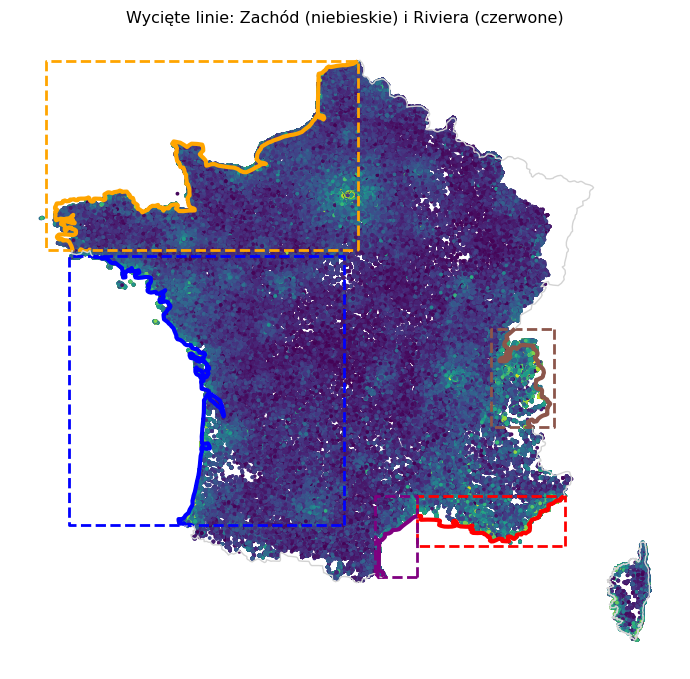

In [23]:
subset = data3[(data3.transaction_id.isin(features_ids)) & (~data3.price_m_2.isin([np.inf, np.nan]))]
subset = subset[subset.price_m_2 < subset.price_m_2.quantile(0.95)]

subset_points = gpd.GeoDataFrame(subset[['price_m_2']], geometry=gpd.points_from_xy(subset.longitude, subset.latitude), crs='EPSG:4326')


fr = gpd.read_file(r"D:\nieruchomosci_ostateczne\coastline\geoBoundaries-FRA-ADM0-all\geoBoundaries-FRA-ADM0.shp").to_crs(4326)

fr_boundary = fr.boundary.iloc[0]

bb_riv  = box(3.96, 42.95, 7.52, 43.79)
bb_lion = box(2.95, 42.42, 3.96, 43.79)
bb_west = box(-4.44, 43.29, 2.2, 47.82)
bb_north = box(-5.0, 47.92, 2.53, 51.10)
bb_border = box(5.73, 46.60, 7.26, 44.94)

riviera_line = gpd.GeoSeries([fr_boundary.intersection(bb_riv)], crs= "EPSG:4326").explode(index_parts = False)
lion_line = gpd.GeoSeries([fr_boundary.intersection(bb_lion)], crs= "EPSG:4326").explode(index_parts = False)
west_line = gpd.GeoSeries([fr_boundary.intersection(bb_west)], crs= "EPSG:4326").explode(index_parts = False)
north_line = gpd.GeoSeries([fr_boundary.intersection(bb_north)], crs= "EPSG:4326").explode(index_parts = False)
border_line = gpd.GeoSeries([fr_boundary.intersection(bb_border)], crs= "EPSG:4326").explode(index_parts = False)


fr_poly_2154 = fr.to_crs(2154).geometry.iloc[0] 


# WYKRES #

# mapa 
fig, ax = plt.subplots(figsize=(7, 9))
gpd.GeoSeries([fr_boundary], crs=4326).plot(ax=ax, color="lightgray", edgecolor="black", linewidth=1)

# punkty 
subset_points.plot(ax=ax, column='price_m_2', cmap='viridis', markersize=3)

# wyznaczone granice 
west_line.plot(ax=ax, color="blue", linewidth=3)
north_line.plot(ax=ax, color="orange", linewidth=3)
riviera_line.plot(ax=ax, color="red", linewidth=3)
lion_line.plot(ax=ax, color='purple', linewidth=3)
border_line.plot(ax=ax, color='tab:brown', linewidth=3)

# wizualizacja jak wyciągamy granice - boksami
gpd.GeoSeries([bb_riv], crs=4326).plot(ax=ax, facecolor="none", edgecolor="red", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_lion], crs=4326).plot(ax=ax, facecolor="none", edgecolor="purple", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_west], crs=4326).plot(ax=ax, facecolor="none", edgecolor="blue", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_north], crs=4326).plot(ax=ax, facecolor="none", edgecolor="orange", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_border], crs=4326).plot(ax=ax, facecolor="none", edgecolor="tab:brown", linestyle="--", linewidth=2)

ax.set_axis_off()
ax.set_title("Wycięte linie: Zachód (niebieskie) i Riviera (czerwone)")
plt.tight_layout()
plt.show()


szacujemy odległość w linii prostej do każdego z wybrzeży i określamy minimalną odległość + które wybrzeże + zmienne indykatorowe określające jak blisko jesteśmy danego brzegu

In [ ]:
geom_points = gpd.GeoSeries(gpd.points_from_xy(data3.longitude, data3.latitude), crs="EPSG:4326").to_crs(2154)

df_borders = pd.DataFrame()

df_borders['dist_north_km'] = geom_points.distance(north_line.to_crs(2154).unary_union) / 1000
df_borders['dist_west_km'] = geom_points.distance(west_line.to_crs(2154).unary_union) / 1000 
df_borders['dist_riviera_km'] = geom_points.distance(riviera_line.to_crs(2154).unary_union) / 1000
df_borders['dist_gulf_lion_km'] = geom_points.distance(lion_line.to_crs(2154).unary_union) / 1000
df_borders['dist_germany_border_segment_km'] = geom_points.distance(border_line.to_crs(2154).unary_union) / 1000

df_borders['min_border_dist_km'] = df_borders.min(axis = 1)
df_borders['border'] = df_borders.idxmin(axis=1)

translate = {
    'dist_north_km': 'north',
    'dist_west_km': 'west',
    'dist_riviera_km': 'riviera',
    'dist_gulf_lion_km': 'gulf_lion',
    'dist_germany_border_segment_km': 'germany_segment'
}

df_borders['border'] = df_borders.border.replace(translate)

for thr in [1, 5, 20]:
    df_borders[f"within_{thr}km_border"] = df_borders.min_border_dist_km <= thr


cols = ['min_border_dist_km', 'border', 'within_1km_border', 'within_5km_border', 'within_20km_border']
data3[cols] = df_borders[cols].values

dict_lines = {'north': north_line, 'west': west_line, 'riviera': riviera_line, 'gulf_lion': lion_line, 'germany_segment': border_line}

In [ ]:
# PRZYKŁAD: odleglość nieruchomości od dużych miast (wybieramy mieszkania daleko od miast, żeby uwypuklić algorytm) #


filtered = data3[(data3["dist_to_big_city_km"] >= 100) & (data3['min_border_dist_km'] > 50)]
points = filtered.sample(3, random_state=123).copy()
nearest_city_idx_sample = points["nearest_city_idx"].values
nearest_border_sample = points['border'].values

fig, ax = plt.subplots(figsize=(7, 7))
fr.to_crs(4326).plot(ax=ax, facecolor="#a6c8ff", edgecolor="blue", linewidth=1, zorder=1)

# Wizualizacja wybranych granic #
north_line.plot(ax=ax, color="orange", linewidth=3, zorder = 2)
west_line.plot(ax=ax, color="blue", linewidth=3, zorder = 2)
riviera_line.plot(ax=ax, color="red", linewidth=3, zorder = 2)
lion_line.plot(ax=ax, color="purple", linewidth=3, zorder = 2)
border_line.plot(ax=ax, color="tab:brown", linewidth=3, zorder = 2)

# MIASTA #

city_points = gpd.GeoSeries(gpd.points_from_xy(city_coords[:, 1], city_coords[:, 0]), crs="EPSG:4326")
city_points_2154 = city_points.to_crs(2154)
city_points.plot(ax=ax, markersize=30, marker="^", color="black", zorder = 10)

for name, lat, lon in big_cities:
    ax.text(lon + 0.3, lat + 0.05, name, fontsize=8, fontweight="bold")

# NIERUCHOMOŚCI #
    
flat_points = gpd.GeoSeries(gpd.points_from_xy(points.longitude, points.latitude), crs="EPSG:4326")
flat_points_2154 = flat_points.to_crs(2154)
flat_points.plot(ax=ax, markersize=30, marker="o", color='red', zorder = 10)

lines2154, lines_cities2154 = [], []
for k in range(len(flat_points_2154)):
    
    POINT = flat_points_2154[k]

    line = dict_lines[nearest_border_sample[k]]
    p_on_coast = nearest_points(POINT, line.to_crs(2154).union_all())[1] 
    
    lines2154.append(LineString([POINT, p_on_coast]))
    lines_cities2154.append(LineString([POINT, city_points_2154.iloc[nearest_city_idx_sample[k]]]))


# Wizualizacja odległości w linii prostej #
gpd.GeoSeries(lines2154, crs=2154).to_crs(4326).plot(ax=ax, color="black", linewidth=1, linestyle="--")
gpd.GeoSeries(lines_cities2154, crs=2154).to_crs(4326).plot(ax=ax, color="red", linewidth=1, linestyle="--")

ax.set_title("Przykładowe nieruchomości z najbliższymi dużymi miasta i wybranymi brzegami")
ax.set_axis_off()

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Nieruchomości', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='^', color='w', label='Duże miasta', markerfacecolor='black', markersize=8),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Odległość do najbliższego dużego miasta'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Odległość do najbliższego wybranego brzegu')]

ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()


data3 = data3.drop(columns = "nearest_city_idx")

4. **czynniki makroekonomiczne**

In [ ]:
# HPI = pd.read_csv('D:\\nieruchomosci_ostateczne\\data\\makroekonomia\\hpi.csv', delimiter = ";").iloc[6:-28]

# HPI.columns = ['Label', 'hpi', 'Code']
# HPI['hpi'] = pd.to_numeric(HPI['hpi'], errors='coerce')
# HPI['year'] = HPI['Label'].astype(str).str[:4].astype(int)
# HPI = HPI.sort_values('Label')
# HPI['quarter'] = np.arange(len(HPI)) % 4 + 1

# # punkt referencyjny = średnia z 2017
# base_2017 = HPI.loc[HPI['year'] == 2017, 'hpi'].mean()
# HPI['hpi'] = 100 * HPI['hpi'] / base_2017

# # data3 = data3.merge(HPI[['hpi', 'year', 'quarter']], how='left', on=['year', 'quarter'])

# hpi_key = (HPI["year"].astype("int32") * 10 + HPI["quarter"].astype("int32"))
# hpi_map = pd.Series(HPI["hpi"].to_numpy(dtype="float32"), index=hpi_key).groupby(level=0).mean()

# data_key = (data3["year"].astype("int32") * 10 + data3["quarter"].astype("int32"))
# data3["hpi"] = data_key.map(hpi_map).astype("float32")

# # cena przeskalowana
# data3['price_adj'] = data3['property_value'] * (100 / data3['hpi'])
# data3['price_m_2_adj'] = data3['price_m_2'] * (100 / data3['hpi'])

zapis danych

In [25]:
data3.to_csv('D:\\nieruchomosci_ostateczne\\samples\\sample3_enhanced.txt', index=False)

średni rok budynków na działce / średnia liczba pięter na działce / dpe

In [1]:
import pandas as pd
import numpy as np

extra_features = pd.read_csv('D:\\nieruchomosci_ostateczne\\data\\work\\rok_dpe.txt', header = None)
data3 = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample3_enhanced.txt')

C:\Users\jpiec\AppData\Local\Temp\ipykernel_23096\167826948.py:5: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data3 = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample3_enhanced.txt')


In [2]:
extra_features.columns = ['parcel_id', 'avg_building_age', 'avg_building_floor', 'dpe_a', 'dpe_b', 'dpe_c', 'dpe_d', 'dpe_e', 'dpe_f', 'dpe_g', 'polygon']
extra_features = extra_features.drop(columns='polygon')
extra_features = extra_features.drop_duplicates('parcel_id')

In [3]:
data4 = data3.merge(extra_features, on='parcel_id', how='left')

cols = ['avg_building_age', 'avg_building_floor', 'dpe_a', 'dpe_b', 'dpe_c', 'dpe_d', 'dpe_e', 'dpe_f', 'dpe_g']
data4[cols] = data4[cols].replace('\\N', np.nan)

In [4]:
cols2 = ['dpe_a', 'dpe_b', 'dpe_c', 'dpe_d', 'dpe_e', 'dpe_f', 'dpe_g']
mask = (data4[cols2] == 0).all(axis=1)
data4.loc[mask, cols2] = np.nan

In [5]:
data4[data4.parcel_id == '01004000AL0435']

,transaction_id,transaction_date,disposition_number,transaction_type,property_value,postal_code,commune_code,commune_name,department_code,parcel_id,...,within_20km_city,avg_building_age,avg_building_floor,dpe_a,dpe_b,dpe_c,dpe_d,dpe_e,dpe_f,dpe_g
5444,2017-5541,2017-04-07,1,Sale,250000.0,1500.0,1004,Ambérieu-en-Bugey,1,01004000AL0435,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2694555,2019-6828,2019-06-26,1,Sale,196000.0,1500.0,1004,Ambérieu-en-Bugey,1,01004000AL0435,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6462134,2022-11474,2022-08-31,1,Sale,485000.0,1500.0,1004,Ambérieu-en-Bugey,1,01004000AL0435,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data4.to_csv('D:\\nieruchomosci_ostateczne\\samples\\sample4_enhanced.txt', index=False)